# Predicción de demanda eléctrica a 24 horas (modelo único)

In [ ]:
from pathlib import Path
from datetime import date, timedelta
import hashlib, json, math, os, warnings

import sklearn
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import joblib

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import requests
import holidays
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

Configuración:

In [ ]:

PROJECT_ROOT = Path()
PROCESSED_DIR = PROJECT_ROOT / 'processed'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts_24h'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CONSUMPTION = PROCESSED_DIR / 'consumption_all_users.parquet'
INPUT_QUALITY = PROCESSED_DIR / 'quality_report.parquet'
INPUT_METADATA = PROCESSED_DIR / 'metadata_filtered.parquet'
FILTERED_CONSUMPTION = PROCESSED_DIR / 'consumption_users_le10pct_imputed.parquet'
WEATHER_PARQUET = PROCESSED_DIR / 'bilbao_weather_hourly.parquet'
LOCAL_HOLIDAYS_CSV = PROCESSED_DIR / 'bilbao_local_holidays.csv'

MAX_IMPUTED_PCT = 10.0
CONSUMPTION_TIMEZONE = 'UTC'
LOCAL_TIMEZONE = 'Europe/Madrid'
FORECAST_ORIGIN_LOCAL_HOUR = 23
FORECAST_HORIZON = 24

# Splits para train, val y test
TRAIN_END_DATE = date(2021, 6, 1)
VAL_END_DATE = date(2021, 12, 1)
TEST_END_DATE = date(2022, 6, 1)
MIN_EVAL_END_UTC = pd.Timestamp('2022-06-02 00:00:00')

# Muestreo para que los primeros experimentos
BASE_TRAIN_DAYS_PER_USER = 60
BASE_VAL_DAYS_PER_USER = 30
TUNE_TRAIN_DAYS_PER_USER = 30
TUNE_VAL_DAYS_PER_USER = 15
FINAL_TRAIN_DAYS_PER_USER = 120
FINAL_VAL_DAYS_PER_USER = 60

RANDOM_SEED = 42
FEATURE_IMPORTANCE_CUMULATIVE_THRESHOLD = 0.95
MIN_SELECTED_FEATURES = 12
MAX_SELECTED_FEATURES = 30
N_OPTUNA_TRIALS = 30

PARQUET_COMPRESSION = 'zstd'
OVERWRITE_FILTERED_PARQUET = False

Excluimos usuarios con más del 10% de imputación:

In [ ]:
quality = pd.read_parquet(INPUT_QUALITY)
quality['user_id'] = quality['user_id'].astype(str)
quality['start_date'] = pd.to_datetime(quality['start_date'])
quality['end_date'] = pd.to_datetime(quality['end_date'])

accepted_mask = quality['status'].eq('ok') & quality['imputed_pct'].le(MAX_IMPUTED_PCT)
quality_ok = quality.loc[accepted_mask].copy()
excluded_users = quality.loc[~accepted_mask].copy()

accepted_users = set(quality_ok['user_id'])
evaluation_users = set(quality_ok.loc[quality_ok['end_date'].ge(MIN_EVAL_END_UTC), 'user_id'])

excluded_users.to_csv(ARTIFACTS_DIR / 'excluded_users_gt10pct_imputed.csv', index=False)

print(f'Usuarios iniciales: {len(quality)}')
print(f'Usuarios aceptados: {len(accepted_users)}')
print(f'Usuarios excluidos: {len(excluded_users)}')
print(f'Usuarios con cobertura completa de evaluación: {len(evaluation_users)}')
display(excluded_users[['user_id','imputed_pct','rows_final']].sort_values('imputed_pct', ascending=False).head(30))

Usuarios iniciales: 1,025
Usuarios aceptados: 1,010
Usuarios excluidos: 15
Usuarios con cobertura completa de evaluación: 923


,user_id,imputed_pct,rows_final
402,66389429a60faabf5a5d8b73a25c0b6d37dcecb4e333f7...,63.917300,41064
953,efe8d8a327e8df89b5906904f6dc2cd7e4a57806a0d477...,60.990676,34320
276,461c48211e7d53887ce74419eba30f3565f333fcfd45d3...,55.270344,43944
978,f471c8f9626d84a950e4774478ddfee413e6a4f0728064...,48.782541,43944
943,ee23472b308a6536b8ec5928be20ea08ed89f75348e1cf...,44.301037,33936
1021,fe73e986873777ffb1973d9ab36485992bebe057ae6bbe...,41.711214,33672
866,dadd1a1228311311a3937be77c2f623040766ef55b80c7...,30.372874,39048
548,8b873da53b135788e0d6b7f2aed92b9537beb65e2963d3...,22.951939,43944
636,a2ada1b5df8539f6479d5f0f6c5bf96ff4318fa4762dca...,18.092593,32400
712,b896709323b7ac9b55308ddafa52851d1f810963a53e6e...,16.798628,30312


In [ ]:
def create_filtered_parquet(input_path, output_path, allowed_users):
    if output_path.exists() and not OVERWRITE_FILTERED_PARQUET:
        print('Ya existe:', output_path)
        return

    tmp = output_path.with_suffix('.tmp.parquet')
    if tmp.exists(): tmp.unlink()
    pf = pq.ParquetFile(input_path)
    writer = None
    n = 0

    try:
        for rg in tqdm(range(pf.num_row_groups), desc='Filtrando usuarios'):
            df = pf.read_row_group(rg).to_pandas()
            df['user_id'] = df['user_id'].astype(str)
            df = df[df['user_id'].isin(allowed_users)]
            if df.empty: continue
            table = pa.Table.from_pandas(df, preserve_index=False)
            if writer is None:
                writer = pq.ParquetWriter(tmp, table.schema, compression=PARQUET_COMPRESSION, write_statistics=True)
            else:
                table = table.cast(writer.schema)
            writer.write_table(table)
            n += len(df)
    finally:
        if writer is not None: writer.close()

    if writer is None:
        raise RuntimeError('No se ha escrito ninguna fila')
    os.replace(tmp, output_path)
    print(f'Filas conservadas: {n}')

create_filtered_parquet(INPUT_CONSUMPTION, FILTERED_CONSUMPTION, accepted_users)

Cargamos los Metadatos estáticos de los usuarios:

In [ ]:
metadata = pd.read_parquet(INPUT_METADATA)
if 'user' in metadata.columns and 'user_id' not in metadata.columns:
    metadata = metadata.rename(columns={'user':'user_id'})
metadata['user_id'] = metadata['user_id'].astype(str)
metadata = metadata[metadata['user_id'].isin(accepted_users)].copy()
for c in ['p1','p2']:
    if c in metadata.columns:
        metadata[c] = pd.to_numeric(metadata[c], errors='coerce')
metadata_lookup = metadata.set_index('user_id')
display(metadata.head())

,user_id,start_date,end_date,length_days,length_years,potential_samples,actual_samples,missing_samples_abs,missing_samples_pct,contract_start_date,contract_end_date,contracted_tariff,self_consumption_type,p1,p2,p3,p4,p5,p6,province,municipality,zip_code,cnae
0,005932ecd8e0888863372c2ca998801ea6a7f2fef1e9dd...,2017-05-31T01:00:00Z,2022-06-05T00:00:00Z,1831.0,5.013005,43944,43824,120,0.273075,2021-06-01,NaN,2.0TD,NaN,4.40,4.40,NaN,NaN,NaN,NaN,Bizkaia,Bilbao,48012.0,9820.0
1,0062c8d5ca7dfed574aab968f665978a9cb770a0d8f325...,2018-12-05T01:00:00Z,2022-06-05T00:00:00Z,1278.0,3.498973,30672,30665,7,0.022822,2021-06-01,NaN,2.0TD,NaN,2.20,2.20,NaN,NaN,NaN,NaN,Bizkaia,Bilbao,48006.0,9820.0
2,00b655f77a0bf8c12323560fa1cd609548ab10782e495b...,2018-09-21T01:00:00Z,2022-06-05T00:00:00Z,1353.0,3.704312,32472,32464,8,0.024637,2021-06-01,NaN,2.0TD,NaN,3.30,3.30,NaN,NaN,NaN,NaN,Bizkaia,Bilbao,48006.0,9820.0
3,00db2f868b1075624b10684c1bbade33552a0490b27e01...,2017-05-31T01:00:00Z,2022-06-05T00:00:00Z,1831.0,5.013005,43944,43121,823,1.872838,2021-06-01,NaN,2.0TD,NaN,3.45,3.45,NaN,NaN,NaN,NaN,Bizkaia,Bilbao,48010.0,9820.0
4,00dcd8d903f75e1f22baa037a7a3ab0fd9bc883614a00c...,2017-05-31T01:00:00Z,2022-06-05T00:00:00Z,1831.0,5.013005,43944,43647,297,0.675860,2021-06-01,NaN,2.0TD,NaN,3.30,3.30,NaN,NaN,NaN,NaN,Bizkaia,Bilbao,48006.0,9820.0


Descargamos la meteorología histórica de Bilbao desde la API de OpenMeteo:

In [ ]:
BILBAO_LAT = 43.2630
BILBAO_LON = -2.9350
WEATHER_API_URL = 'https://archive-api.open-meteo.com/v1/archive'
WEATHER_VARIABLES = ['temperature_2m','apparent_temperature','relative_humidity_2m',
                     'precipitation','cloud_cover','wind_speed_10m']

def download_weather(start_date, end_date, output_path):
    params = {
        'latitude': BILBAO_LAT,
        'longitude': BILBAO_LON,
        'start_date': str(start_date),
        'end_date': str(end_date),
        'hourly': ','.join(WEATHER_VARIABLES),
        'timezone': 'GMT'
    }
    r = requests.get(WEATHER_API_URL, params=params, timeout=120)
    r.raise_for_status()
    payload = r.json()
    hourly = pd.DataFrame(payload['hourly'])
    hourly['Fecha'] = pd.to_datetime(hourly.pop('time'))
    for c in WEATHER_VARIABLES:
        hourly[c] = pd.to_numeric(hourly[c], errors='coerce').astype('float32')
    hourly.to_parquet(output_path, index=False, compression=PARQUET_COMPRESSION)
    return hourly

weather_start = (quality_ok['start_date'].min() - pd.Timedelta(days=10)).date()
weather_end = (quality_ok['end_date'].max() + pd.Timedelta(days=2)).date()

if WEATHER_PARQUET.exists():
    weather = pd.read_parquet(WEATHER_PARQUET)
else:
    weather = download_weather(weather_start, weather_end, WEATHER_PARQUET)

weather['Fecha'] = pd.to_datetime(weather['Fecha'])
weather_hourly = weather.drop_duplicates('Fecha').sort_values('Fecha').set_index('Fecha')

wd = weather_hourly.reset_index()
wd['local_date'] = pd.DatetimeIndex(wd['Fecha']).tz_localize('UTC').tz_convert(LOCAL_TIMEZONE).date
weather_daily_local = wd.groupby('local_date').agg(
    weather_temp_mean=('temperature_2m','mean'),
    weather_temp_min=('temperature_2m','min'),
    weather_temp_max=('temperature_2m','max'),
    weather_precip_sum=('precipitation','sum'),
).astype('float32')

display(weather_hourly.head())

,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m
Fecha,,,,,,
2017-05-18 00:00:00,14.1,13.2,92.0,0.5,100.0,12.8
2017-05-18 01:00:00,13.9,13.0,92.0,1.2,100.0,11.7
2017-05-18 02:00:00,13.9,13.4,91.0,1.2,100.0,8.1
2017-05-18 03:00:00,13.7,12.2,94.0,2.1,100.0,16.1
2017-05-18 04:00:00,13.4,11.7,95.0,0.7,100.0,17.4


Festivos de Bilbao:

In [ ]:
years = range(quality_ok['start_date'].min().year, quality_ok['end_date'].max().year + 1)
pv_holidays = holidays.country_holidays('ES', subdiv='PV', years=years, language='es')
pv_holiday_dates = set(pv_holidays.keys())

bilbao_local_holiday_dates = set()
if LOCAL_HOLIDAYS_CSV.exists():
    lh = pd.read_csv(LOCAL_HOLIDAYS_CSV)
    lh['date'] = pd.to_datetime(lh['date']).dt.date
    bilbao_local_holiday_dates = set(lh['date'])

all_holiday_dates = pv_holiday_dates | bilbao_local_holiday_dates
print('Festivos ES/PV:', len(pv_holiday_dates))
print('Festivos locales Bilbao:', len(bilbao_local_holiday_dates))

Ingeniería de variables multi-horizonte:

In [14]:
def stable_user_seed(user_id, base_seed=RANDOM_SEED):
    digest = hashlib.sha256(f'{base_seed}-{user_id}'.encode()).hexdigest()[:8]
    return int(digest, 16)

def to_local_time(naive_utc):
    return pd.DatetimeIndex(naive_utc).tz_localize(CONSUMPTION_TIMEZONE).tz_convert(LOCAL_TIMEZONE)

def split_from_date(d):
    if d < TRAIN_END_DATE: return 'train'
    if d < VAL_END_DATE: return 'validation'
    if d < TEST_END_DATE: return 'test'
    return 'unused'

def holiday_arrays(local_dates):
    pv = np.array([d in pv_holiday_dates for d in local_dates], dtype='uint8')
    loc = np.array([d in bilbao_local_holiday_dates for d in local_dates], dtype='uint8')
    hol = np.maximum(pv, loc).astype('uint8')
    before = np.array([(d + timedelta(days=1)) in all_holiday_dates for d in local_dates], dtype='uint8')
    after = np.array([(d - timedelta(days=1)) in all_holiday_dates for d in local_dates], dtype='uint8')
    return pv, loc, hol, before, after

In [ ]:
def build_forecast_rows_for_user(user_df, split_day_limits):
    df = user_df.copy()
    df['user_id'] = df['user_id'].astype(str)
    df['Fecha'] = pd.to_datetime(df['Fecha'])
    df = df.sort_values('Fecha').drop_duplicates('Fecha', keep='last').reset_index(drop=True)
    if df.empty: return pd.DataFrame()

    user_id = df['user_id'].iloc[0]
    s = pd.to_numeric(df['consumo'], errors='coerce').astype('float64')
    imp = pd.to_numeric(df['imputed'], errors='coerce').fillna(0).astype('uint8')
    ts = pd.DatetimeIndex(df['Fecha'])
    local = to_local_time(df['Fecha'])

    diffs = pd.Series(ts).diff().dropna()
    if not (diffs == pd.Timedelta(hours=1)).all():
        raise ValueError(f'Serie no horaria/continua: {user_id}')

    r24 = s.rolling(24, min_periods=24)
    r168 = s.rolling(168, min_periods=168)
    scale = s.rolling(24*28, min_periods=24*7).mean()
    imp24 = imp.astype(float).rolling(24, min_periods=1).mean()
    imp168 = imp.astype(float).rolling(168, min_periods=1).mean()

    idx = np.arange(len(df))
    mask = (
        (np.asarray(local.hour) == FORECAST_ORIGIN_LOCAL_HOUR)
        & (idx >= 336)
        & (idx + FORECAST_HORIZON < len(df))
        & scale.notna().to_numpy()
    )
    origins = idx[mask]
    if len(origins) == 0: return pd.DataFrame()

    forecast_dates = np.asarray(local[origins + 1].date)
    splits = np.array([split_from_date(d) for d in forecast_dates], dtype=object)
    rng = np.random.default_rng(stable_user_seed(user_id))
    chosen_chunks = []

    for split_name, max_days in split_day_limits.items():
        pos = np.flatnonzero(splits == split_name)
        if len(pos) == 0: continue
        if max_days is not None and len(pos) > max_days:
            pos = np.sort(rng.choice(pos, size=max_days, replace=False))
        chosen_chunks.append(pos)

    if not chosen_chunks: return pd.DataFrame()
    chosen = np.sort(np.concatenate(chosen_chunks))
    origins, forecast_dates, splits = origins[chosen], forecast_dates[chosen], splits[chosen]

    p1 = p2 = np.nan
    if user_id in metadata_lookup.index:
        if 'p1' in metadata_lookup.columns: p1 = metadata_lookup.at[user_id, 'p1']
        if 'p2' in metadata_lookup.columns: p2 = metadata_lookup.at[user_id, 'p2']

    blocks=[]
    for h in range(1, FORECAST_HORIZON+1):
        tp = origins + h
        target_ts = ts[tp]
        target_local = local[tp]
        dates = np.asarray(target_local.date)
        pv, loc_h, hol, before, after = holiday_arrays(dates)
        hour = np.asarray(target_local.hour)
        dow = np.asarray(target_local.dayofweek)
        month = np.asarray(target_local.month)
        doy = np.asarray(target_local.dayofyear)
        w = weather_hourly.reindex(pd.DatetimeIndex(target_ts))
        daily = weather_daily_local.reindex(dates)
        sc = scale.iloc[origins].to_numpy()
        lag24 = s.iloc[tp-24].to_numpy(); lag168 = s.iloc[tp-168].to_numpy(); lag336 = s.iloc[tp-336].to_numpy()
        y = s.iloc[tp].to_numpy()

        b = pd.DataFrame({
            'user_id': user_id,
            'origin_time_utc': ts[origins],
            'target_time_utc': target_ts,
            'forecast_date': forecast_dates,
            'split': splits,
            'target': y.astype('float32'),
            'target_imputed': imp.iloc[tp].to_numpy().astype('uint8'),
            'scale_28d': sc.astype('float32'),
            'target_rel': (y/np.maximum(sc,1e-6)).astype('float32'),
            'horizon': np.int8(h),
            'target_hour': hour.astype('int8'),
            'target_dayofweek': dow.astype('int8'),
            'target_month': month.astype('int8'),
            'target_dayofyear': doy.astype('int16'),
            'target_is_weekend': (dow>=5).astype('uint8'),
            'target_hour_sin': np.sin(2*np.pi*hour/24).astype('float32'),
            'target_hour_cos': np.cos(2*np.pi*hour/24).astype('float32'),
            'target_dow_sin': np.sin(2*np.pi*dow/7).astype('float32'),
            'target_dow_cos': np.cos(2*np.pi*dow/7).astype('float32'),
            'target_doy_sin': np.sin(2*np.pi*doy/365.25).astype('float32'),
            'target_doy_cos': np.cos(2*np.pi*doy/365.25).astype('float32'),
            'is_public_holiday_pv': pv,
            'is_bilbao_local_holiday': loc_h,
            'is_holiday': hol,
            'is_day_before_holiday': before,
            'is_day_after_holiday': after,
            'last_consumption_rel': (s.iloc[origins].to_numpy()/np.maximum(sc,1e-6)).astype('float32'),
            'rolling_mean_24_rel': (r24.mean().iloc[origins].to_numpy()/np.maximum(sc,1e-6)).astype('float32'),
            'rolling_mean_168_rel': (r168.mean().iloc[origins].to_numpy()/np.maximum(sc,1e-6)).astype('float32'),
            'rolling_std_24': r24.std().iloc[origins].to_numpy().astype('float32'),
            'rolling_std_168': r168.std().iloc[origins].to_numpy().astype('float32'),
            'rolling_min_24': r24.min().iloc[origins].to_numpy().astype('float32'),
            'rolling_max_24': r24.max().iloc[origins].to_numpy().astype('float32'),
            'rolling_min_168': r168.min().iloc[origins].to_numpy().astype('float32'),
            'rolling_max_168': r168.max().iloc[origins].to_numpy().astype('float32'),
            'past_imputed_frac_24': imp24.iloc[origins].to_numpy().astype('float32'),
            'past_imputed_frac_168': imp168.iloc[origins].to_numpy().astype('float32'),
            'lag_24_target_rel': (lag24/np.maximum(sc,1e-6)).astype('float32'),
            'lag_168_target_rel': (lag168/np.maximum(sc,1e-6)).astype('float32'),
            'lag_336_target_rel': (lag336/np.maximum(sc,1e-6)).astype('float32'),
            'lag_24_target': lag24.astype('float32'),
            'lag_168_target': lag168.astype('float32'),
            'lag_336_target': lag336.astype('float32'),
            'lag_24_target_imputed': imp.iloc[tp-24].to_numpy().astype('uint8'),
            'lag_168_target_imputed': imp.iloc[tp-168].to_numpy().astype('uint8'),
            'lag_336_target_imputed': imp.iloc[tp-336].to_numpy().astype('uint8'),
            'contracted_power_p1': np.float32(p1) if pd.notna(p1) else np.nan,
            'contracted_power_p2': np.float32(p2) if pd.notna(p2) else np.nan,
            'temperature_2m': w['temperature_2m'].to_numpy(dtype='float32'),
            'apparent_temperature': w['apparent_temperature'].to_numpy(dtype='float32'),
            'relative_humidity_2m': w['relative_humidity_2m'].to_numpy(dtype='float32'),
            'precipitation': w['precipitation'].to_numpy(dtype='float32'),
            'cloud_cover': w['cloud_cover'].to_numpy(dtype='float32'),
            'wind_speed_10m': w['wind_speed_10m'].to_numpy(dtype='float32'),
            'weather_temp_mean': daily['weather_temp_mean'].to_numpy(dtype='float32'),
            'weather_temp_min': daily['weather_temp_min'].to_numpy(dtype='float32'),
            'weather_temp_max': daily['weather_temp_max'].to_numpy(dtype='float32'),
            'weather_precip_sum': daily['weather_precip_sum'].to_numpy(dtype='float32')
        })
        blocks.append(b)

    out = pd.concat(blocks, ignore_index=True)
    return out[out['target'].notna() & out['scale_28d'].notna()].copy()

Features base y comprobación de un usuario:

In [17]:
FEATURE_COLUMNS_BASE = [
    'horizon','target_hour','target_dayofweek','target_month','target_dayofyear','target_is_weekend',
    'target_hour_sin','target_hour_cos','target_dow_sin','target_dow_cos','target_doy_sin','target_doy_cos',
    'is_public_holiday_pv','is_bilbao_local_holiday','is_holiday','is_day_before_holiday','is_day_after_holiday',
    'last_consumption_rel','rolling_mean_24_rel','rolling_mean_168_rel','rolling_std_24','rolling_std_168',
    'rolling_min_24','rolling_max_24','rolling_min_168','rolling_max_168','past_imputed_frac_24','past_imputed_frac_168',
    'lag_24_target_rel','lag_168_target_rel','lag_336_target_rel',
    'lag_24_target_imputed','lag_168_target_imputed','lag_336_target_imputed',
    'contracted_power_p1','contracted_power_p2',
    'temperature_2m','apparent_temperature','relative_humidity_2m','precipitation','cloud_cover','wind_speed_10m',
    'weather_temp_mean','weather_temp_min','weather_temp_max','weather_precip_sum'
]
print('Nº features base:', len(FEATURE_COLUMNS_BASE))

pf = pq.ParquetFile(FILTERED_CONSUMPTION)
example = pf.read_row_group(0).to_pandas()
example_rows = build_forecast_rows_for_user(example, {'train':2,'validation':1,'test':1})
display(example_rows.head(10))

Nº features base: 46


,user_id,origin_time_utc,target_time_utc,forecast_date,split,target,target_imputed,scale_28d,target_rel,horizon,target_hour,target_dayofweek,target_month,target_dayofyear,target_is_weekend,target_hour_sin,target_hour_cos,target_dow_sin,target_dow_cos,target_doy_sin,target_doy_cos,is_public_holiday_pv,is_bilbao_local_holiday,is_holiday,is_day_before_holiday,is_day_after_holiday,last_consumption_rel,rolling_mean_24_rel,rolling_mean_168_rel,rolling_std_24,rolling_std_168,rolling_min_24,rolling_max_24,rolling_min_168,rolling_max_168,past_imputed_frac_24,past_imputed_frac_168,lag_24_target_rel,lag_168_target_rel,lag_336_target_rel,lag_24_target,lag_168_target,lag_336_target,lag_24_target_imputed,lag_168_target_imputed,lag_336_target_imputed,contracted_power_p1,contracted_power_p2,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m,weather_temp_mean,weather_temp_min,weather_temp_max,weather_precip_sum
0,005932ecd8e0888863372c2ca998801ea6a7f2fef1e9dd...,2017-11-15 22:00:00,2017-11-15 23:00:00,2017-11-16,train,0.225,0,0.145353,1.547951,1,0,3,11,320,0,0.000000,1.000000,0.433884,-0.900969,-0.702148,0.712031,0,0,0,0,0,1.754345,1.199376,1.104819,0.159421,0.164496,0.048,0.664,0.036,1.277,0.0,0.000000,1.389716,1.320918,1.465394,0.202,0.192,0.213,0,0,0,4.4,4.4,4.1,1.6,95.0,0.0,0.0,6.0,8.504167,3.1,15.400000,0.0
1,005932ecd8e0888863372c2ca998801ea6a7f2fef1e9dd...,2018-03-28 21:00:00,2018-03-28 22:00:00,2018-03-29,train,0.034,0,0.146393,0.232252,1,0,3,3,88,0,0.000000,1.000000,0.433884,-0.900969,0.998377,0.056952,1,0,1,1,0,0.327885,0.779296,0.818533,0.111340,0.143859,0.028,0.537,0.023,0.982,0.0,0.005952,1.338863,1.004147,0.990485,0.196,0.147,0.145,0,0,0,4.4,4.4,9.2,7.3,95.0,0.5,100.0,10.7,11.258334,8.6,16.700001,6.0
2,005932ecd8e0888863372c2ca998801ea6a7f2fef1e9dd...,2021-07-30 21:00:00,2021-07-30 22:00:00,2021-07-31,validation,0.052,0,0.161302,0.322376,1,0,5,7,212,1,0.000000,1.000000,-0.974928,-0.222521,-0.484089,-0.875019,0,0,0,0,0,0.322376,1.083371,0.946538,0.142495,0.195350,0.052,0.721,0.048,1.657,0.0,0.000000,1.382499,0.799742,0.328576,0.223,0.129,0.053,0,0,0,4.4,4.4,17.6,18.1,83.0,0.1,100.0,7.2,16.525000,15.3,17.600000,9.7
3,005932ecd8e0888863372c2ca998801ea6a7f2fef1e9dd...,2022-01-25 22:00:00,2022-01-25 23:00:00,2022-01-26,test,0.748,0,0.219985,3.400230,1,0,2,1,26,0,0.000000,1.000000,0.974928,-0.222521,0.432499,0.901634,0,0,0,0,0,1.672840,0.633187,0.759738,0.110679,0.151507,0.057,0.512,0.053,1.011,0.0,0.000000,0.881878,1.100074,1.009159,0.194,0.242,0.222,0,0,0,4.4,4.4,2.4,-0.9,90.0,0.0,0.0,8.5,5.700000,1.3,13.700000,0.0
4,005932ecd8e0888863372c2ca998801ea6a7f2fef1e9dd...,2017-11-15 22:00:00,2017-11-16 00:00:00,2017-11-16,train,0.114,0,0.145353,0.784295,2,1,3,11,320,0,0.258819,0.965926,0.433884,-0.900969,-0.702148,0.712031,0,0,0,0,0,1.754345,1.199376,1.104819,0.159421,0.164496,0.048,0.664,0.036,1.277,0.0,0.000000,0.873732,0.743017,1.025088,0.127,0.108,0.149,0,0,0,4.4,4.4,5.5,2.9,87.0,0.0,0.0,7.1,8.504167,3.1,15.400000,0.0
5,005932ecd8e0888863372c2ca998801ea6a7f2fef1e9dd...,2018-03-28 21:00:00,2018-03-28 23:00:00,2018-03-29,train,0.050,0,0.146393,0.341547,2,1,3,3,88,0,0.258819,0.965926,0.433884,-0.900969,0.998377,0.056952,1,0,1,1,0,0.327885,0.779296,0.818533,0.111340,0.143859,0.028,0.537,0.023,0.982,0.0,0.005952,1.414003,1.277385,1.106611,0.207,0.187,0.162,0,0,0,4.4,4.4,9.1,7.1,94.0,0.5,98.0,9.8,11.258334,8.6,16.700001,6.0
6,005932ecd8e0888863372c2ca998801ea6a7f2fef1e9dd...,2021-07-30 21:00:00,2021-07-30 23:00:00,2021-07-31,validation,0.057,0,0.161302,0.353374,2,1,5,7,212,1,0.258819,0.965926,-0.974928,-0.222521,-0.484089,-0.875019,0,0,0,0,0,0.322376,1.083371,0.946538,0.142495,0.195350,0.052,0.721,0.048,1.657,0.0,0.000000,1.295706,1.066322,0.340975,0.209,0.172,0.055,0,0,0,4.4,4.4,17.5,18.1,83.0,0.1,100.0,6.4,16.525000,15.3,17.600000,9.7
7,005932ecd8e0888863372c2ca998801ea6a7f2fef1e9dd...,2022-01-25 22:00:00,2022-01-26 00:00:00,2022-01-26,test,0.144,0,0.219985,0.654590,2,1,2,1,26,0,0.258819,0.965

Crear muestras equilibradas de train/val :

In [18]:
def build_sample_dataset(split_day_limits, allowed_user_ids=None):
    pf = pq.ParquetFile(FILTERED_CONSUMPTION)
    chunks=[]
    for rg in tqdm(range(pf.num_row_groups), desc=f'Muestra {split_day_limits}'):
        g = pf.read_row_group(rg).to_pandas()
        for uid, udf in g.groupby('user_id', sort=False):
            uid = str(uid)
            if allowed_user_ids is not None and uid not in allowed_user_ids: continue
            rows = build_forecast_rows_for_user(udf, split_day_limits)
            if not rows.empty: chunks.append(rows)
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()

base_sample = build_sample_dataset({'train':BASE_TRAIN_DAYS_PER_USER,'validation':BASE_VAL_DAYS_PER_USER})
base_train = base_sample[(base_sample['split']=='train') & (base_sample['target_imputed']==0)].copy()
base_val = base_sample[(base_sample['split']=='validation') & (base_sample['target_imputed']==0) & base_sample['user_id'].isin(evaluation_users)].copy()
print(f'Train: {len(base_train):,} | Validation: {len(base_val):,}')

Muestra {'train': 60, 'validation': 30}:   0%|          | 0/1010 [00:00<?, ?it/s]

Muestra {'train': 60, 'validation': 30}: 100%|██████████| 1010/1010 [14:39<00:00,  1.15it/s]


Train: 1,448,983 | Validation: 664,435


Métricas y baselines:

In [ ]:
def regression_metrics(y_true, y_pred):
    y_true=np.asarray(y_true,dtype=float); y_pred=np.asarray(y_pred,dtype=float)
    valid=np.isfinite(y_true)&np.isfinite(y_pred); y_true=y_true[valid]; y_pred=y_pred[valid]
    err=y_pred-y_true
    return {
        'n':len(y_true),
        'MAE':np.mean(np.abs(err)),
        'RMSE':np.sqrt(np.mean(err**2)),
        'WAPE_pct':100*np.sum(np.abs(err))/max(np.sum(np.abs(y_true)),1e-8),
        'sMAPE_pct':100*np.mean(2*np.abs(err)/np.maximum(np.abs(y_true)+np.abs(y_pred),1e-8)),
        'R2':float(r2_score(y_true,y_pred)),
    }

def predictions_to_kwh(pred_rel, scale):
    return np.maximum(np.asarray(pred_rel)*np.asarray(scale), 0.0)

def eval_predictions(df, pred, name):
    rows=[{'model':name,'scope':'overall','horizon':0,**regression_metrics(df['target'],pred)}]
    pser=pd.Series(np.asarray(pred), index=df.index)
    for h, idx in df.groupby('horizon').groups.items():
        idx=list(idx)
        rows.append({'model':name,'scope':'horizon','horizon':int(h),**regression_metrics(df.loc[idx,'target'],pser.loc[idx])})
    return pd.DataFrame(rows)

baseline_results=[]
for name,pred in {
    'Naive_D-1':base_val['lag_24_target'].to_numpy(),
    'Naive_W-1':base_val['lag_168_target'].to_numpy(),
    'Naive_mean_D1_W1':(base_val['lag_24_target'].to_numpy()+base_val['lag_168_target'].to_numpy())/2,
}.items():
    baseline_results.append(eval_predictions(base_val,pred,name))
baseline_results=pd.concat(baseline_results,ignore_index=True)
display(baseline_results[baseline_results.scope=='overall'].sort_values('WAPE_pct'))

,model,scope,horizon,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
50,Naive_mean_D1_W1,overall,0,664435,0.107977,0.226106,60.679747,49.718039,0.298527
0,Naive_D-1,overall,0,664435,0.119187,0.264827,66.979215,50.880141,0.037695
25,Naive_W-1,overall,0,664435,0.121393,0.264608,68.219007,54.176048,0.039284


Modelos base: LightGBM, XGBoost y CatBoost:

In [ ]:
MODEL_NAMES=['LightGBM','XGBoost','CatBoost']

def default_params(name):
    if name=='LightGBM':
        return dict(objective='regression_l1',n_estimators=500,learning_rate=.05,num_leaves=63,max_depth=-1,min_child_samples=80,subsample=.9,colsample_bytree=.9,reg_lambda=1.,random_state=RANDOM_SEED,n_jobs=-1,verbosity=-1)
    if name=='XGBoost':
        return dict(objective='reg:squarederror',n_estimators=500,learning_rate=.05,max_depth=8,min_child_weight=5,subsample=.9,colsample_bytree=.9,reg_lambda=1.,tree_method='hist',random_state=RANDOM_SEED,n_jobs=-1)
    if name=='CatBoost':
        return dict(loss_function='MAE',iterations=500,learning_rate=.05,depth=8,l2_leaf_reg=3.,random_seed=RANDOM_SEED,verbose=False,allow_writing_files=False,thread_count=-1)
    raise ValueError(name)

def build_model(name, params=None):
    p=default_params(name)
    if params: p.update(params)
    if name=='LightGBM': return LGBMRegressor(**p)
    if name=='XGBoost': return XGBRegressor(**p)
    if name=='CatBoost': return CatBoostRegressor(**p)
    raise ValueError(name)

def prepare_xy(df, features):
    X=df[features].replace([np.inf,-np.inf],np.nan).astype('float32')
    y=df['target_rel'].astype('float32')
    return X,y

Xtr,ytr=prepare_xy(base_train,FEATURE_COLUMNS_BASE)
Xva,yva=prepare_xy(base_val,FEATURE_COLUMNS_BASE)
base_models={}; base_results=[]
for name in MODEL_NAMES:
    print('Entrenando',name)
    m=build_model(name); m.fit(Xtr,ytr); base_models[name]=m
    joblib.dump(m,ARTIFACTS_DIR/f'{name}_base.pkl')
    joblib.dump(FEATURE_COLUMNS_BASE,ARTIFACTS_DIR/f'{name}_base_features.pkl')
    pred=predictions_to_kwh(m.predict(Xva),base_val['scale_28d'])
    base_results.append(eval_predictions(base_val,pred,f'{name}_base'))
base_results=pd.concat(base_results,ignore_index=True)
display(base_results[base_results.scope=='overall'].sort_values('WAPE_pct'))

Entrenando LightGBM
Entrenando XGBoost
Entrenando CatBoost


,model,scope,horizon,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,LightGBM_base,overall,0,664435,0.088015,0.210743,49.461667,43.602306,0.390614
50,CatBoost_base,overall,0,664435,0.088210,0.228170,49.571088,43.502382,0.285659
25,XGBoost_base,overall,0,664435,0.187355,9.763267,105.287255,55.650601,-1306.910576


Feature importance y selección por algoritmo:

LightGBM 46 -> 17


,feature,importance,importance_norm,importance_cumulative
0,lag_24_target_rel,4.618841e+06,0.374320,0.374320
1,lag_168_target_rel,1.807998e+06,0.146524,0.520844
2,lag_336_target_rel,9.642690e+05,0.078146,0.598990
3,target_hour_sin,7.510790e+05,0.060869,0.659859
4,last_consumption_rel,6.904851e+05,0.055958,0.715817
5,rolling_mean_24_rel,6.535250e+05,0.052963,0.768780
6,horizon,3.539303e+05,0.028683,0.797464
7,rolling_std_168,3.312784e+05,0.026847,0.824311
8,rolling_mean_168_rel,3.254527e+05,0.026375,0.850686
9,rolling_std_24,2.657819e+05,0.021540,0.872226


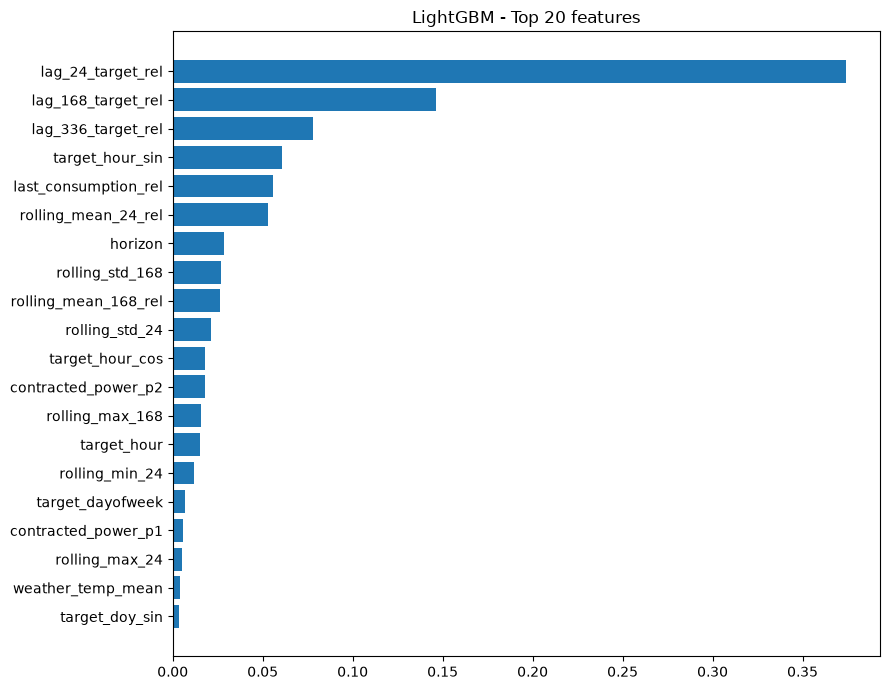

XGBoost 46 -> 20


,feature,importance,importance_norm,importance_cumulative
0,horizon,0.195133,0.195133,0.195133
1,target_dayofyear,0.167980,0.167980,0.363113
2,target_hour,0.141895,0.141895,0.505009
3,target_month,0.076314,0.076314,0.581322
4,target_is_weekend,0.073744,0.073744,0.655066
5,target_dayofweek,0.058657,0.058657,0.713724
6,apparent_temperature,0.058021,0.058021,0.771744
7,weather_temp_min,0.048623,0.048623,0.820367
8,target_hour_sin,0.029134,0.029134,0.849501
9,weather_precip_sum,0.018489,0.018489,0.867990


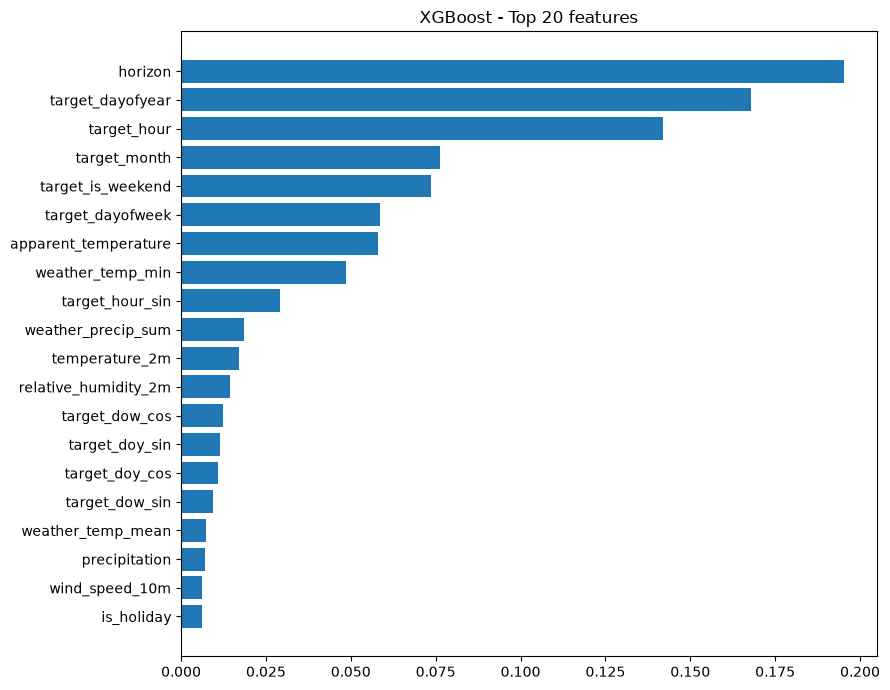

CatBoost 46 -> 16


,feature,importance,importance_norm,importance_cumulative
0,rolling_mean_168_rel,30.337943,0.303379,0.303379
1,is_public_holiday_pv,29.240609,0.292406,0.595786
2,temperature_2m,25.930685,0.259307,0.855092
3,target_hour,7.044711,0.070447,0.925539
4,target_dow_sin,7.044313,0.070443,0.995983
5,last_consumption_rel,0.057999,0.000580,0.996563
6,rolling_std_168,0.052206,0.000522,0.997085
7,contracted_power_p2,0.044846,0.000448,0.997533
8,lag_24_target_rel,0.043941,0.000439,0.997973
9,lag_168_target_rel,0.037574,0.000376,0.998348


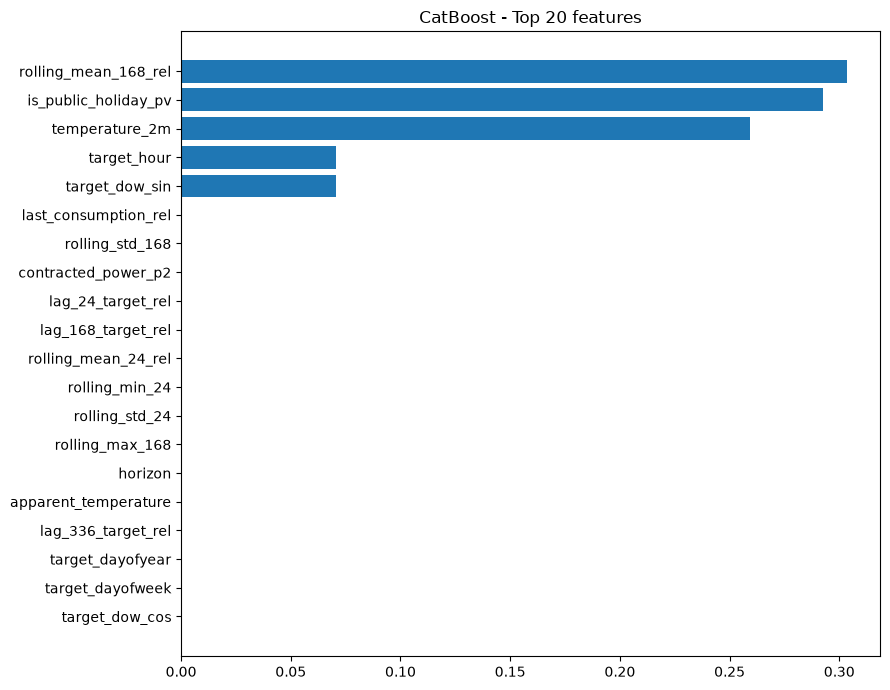

In [ ]:
PROTECTED_FEATURES=['horizon','target_hour_sin','target_hour_cos','target_dow_sin','target_dow_cos','lag_24_target_rel','lag_168_target_rel']

def importance_df(name, model, features):
    if name=='LightGBM': imp=model.booster_.feature_importance(importance_type='gain')
    elif name=='XGBoost': imp=model.feature_importances_
    else: imp=model.get_feature_importance()
    out=pd.DataFrame({'feature':features,'importance':np.asarray(imp,dtype=float)})
    total=out.importance.sum(); out['importance_norm']=out.importance/total if total>0 else 1/len(out)
    out=out.sort_values('importance_norm',ascending=False).reset_index(drop=True)
    out['importance_cumulative']=out.importance_norm.cumsum()
    return out

def select_features(imp):
    cum=imp.importance_cumulative.to_numpy(); n_auto=int(np.argmax(cum>=FEATURE_IMPORTANCE_CUMULATIVE_THRESHOLD))+1
    n=max(MIN_SELECTED_FEATURES,n_auto); n=min(MAX_SELECTED_FEATURES,n)
    selected=imp.feature.iloc[:n].tolist()
    for f in PROTECTED_FEATURES:
        if f not in selected: selected.append(f)
    return selected

feature_importances={}; selected_features={}
for name,m in base_models.items():
    imp=importance_df(name,m,FEATURE_COLUMNS_BASE); feature_importances[name]=imp; selected_features[name]=select_features(imp)
    imp.to_csv(ARTIFACTS_DIR/f'{name}_feature_importance.csv',index=False)
    joblib.dump(selected_features[name],ARTIFACTS_DIR/f'{name}_selected_features.pkl')
    print(name, len(FEATURE_COLUMNS_BASE),'->',len(selected_features[name]))
    display(imp.head(20))
    top=imp.head(20).sort_values('importance_norm')
    plt.figure(figsize=(9,7)); plt.barh(top.feature,top.importance_norm); plt.title(f'{name} - Top 20 features'); plt.tight_layout(); plt.show()

Reentrenar modelos con features seleccionadas y comparar las 6 variantes:

,model,scope,horizon,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,LightGBM_base,overall,0,664435,0.088015,0.210743,49.461667,43.602306,0.390614
1,LightGBM_selected,overall,0,664435,0.088038,0.210398,49.474588,43.233990,0.392605
2,CatBoost_base,overall,0,664435,0.088210,0.228170,49.571088,43.502382,0.285659
3,CatBoost_selected,overall,0,664435,0.089365,0.213182,50.220255,44.179491,0.376422
4,Naive_mean_D1_W1,overall,0,664435,0.107977,0.226106,60.679747,49.718039,0.298527
5,Naive_D-1,overall,0,664435,0.119187,0.264827,66.979215,50.880141,0.037695
6,Naive_W-1,overall,0,664435,0.121393,0.264608,68.219007,54.176048,0.039284
7,XGBoost_base,overall,0,664435,0.187355,9.763267,105.287255,55.650601,-1306.910576
8,XGBoost_selected,overall,0,664435,0.254098,23.222980,142.795026,57.207400,-7398.861604


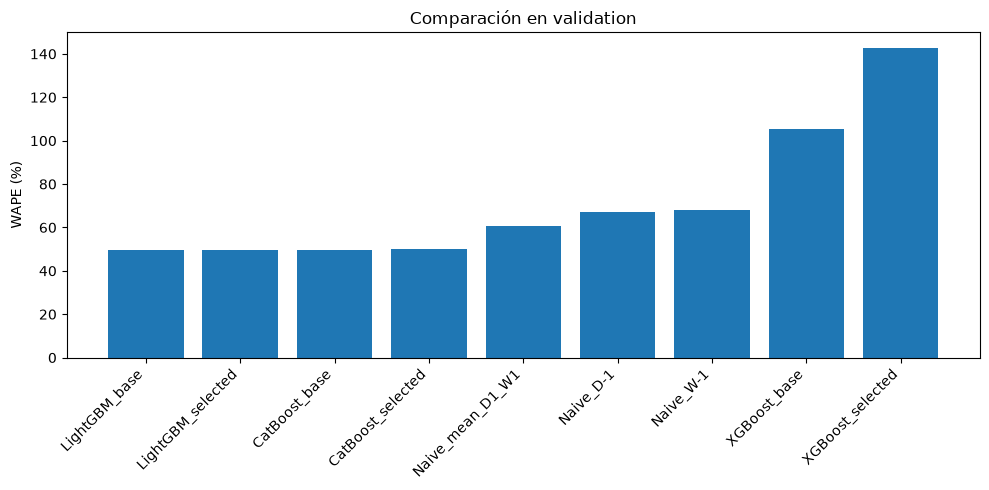

In [ ]:
selected_models={}; selected_results=[]
for name in MODEL_NAMES:
    feats=selected_features[name]
    Xtr2,ytr2=prepare_xy(base_train,feats); Xva2,yva2=prepare_xy(base_val,feats)
    m=build_model(name); m.fit(Xtr2,ytr2); selected_models[name]=m
    joblib.dump(m,ARTIFACTS_DIR/f'{name}_selected.pkl')
    pred=predictions_to_kwh(m.predict(Xva2),base_val['scale_28d'])
    selected_results.append(eval_predictions(base_val,pred,f'{name}_selected'))
selected_results=pd.concat(selected_results,ignore_index=True)

validation_all=pd.concat([baseline_results,base_results,selected_results],ignore_index=True)
validation_overall=validation_all[validation_all.scope=='overall'].sort_values(['WAPE_pct','MAE']).reset_index(drop=True)
validation_overall.to_csv(ARTIFACTS_DIR/'validation_model_comparison.csv',index=False)
display(validation_overall)

plt.figure(figsize=(10,5)); p=validation_overall.sort_values('WAPE_pct'); plt.bar(p.model,p.WAPE_pct); plt.xticks(rotation=45,ha='right'); plt.ylabel('WAPE (%)'); plt.title('Comparación en validation'); plt.tight_layout(); plt.show()

Ganador pre-Optuna: LightGBM_base
Features: 46


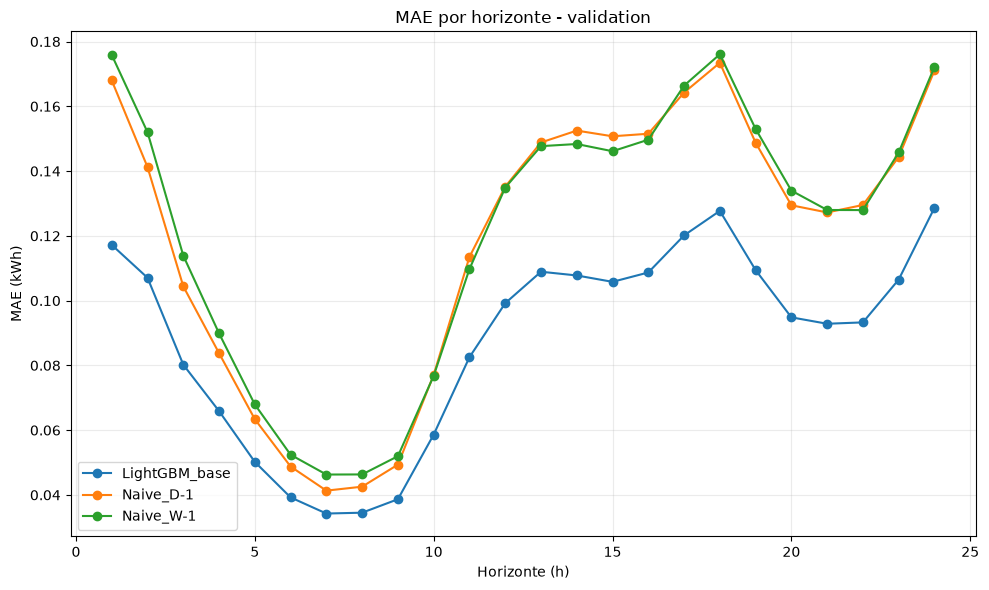

In [ ]:
ml_candidates=validation_overall[validation_overall.model.str.startswith(tuple(MODEL_NAMES))]
BEST_VARIANT_NAME=ml_candidates.iloc[0].model
if BEST_VARIANT_NAME.endswith('_base'):
    BEST_MODEL_NAME=BEST_VARIANT_NAME.replace('_base',''); BEST_FEATURES=FEATURE_COLUMNS_BASE
else:
    BEST_MODEL_NAME=BEST_VARIANT_NAME.replace('_selected',''); BEST_FEATURES=selected_features[BEST_MODEL_NAME]
print('Ganador pre-Optuna:',BEST_VARIANT_NAME)
print('Features:',len(BEST_FEATURES))
joblib.dump(BEST_FEATURES,ARTIFACTS_DIR/'best_preoptuna_features.pkl')

plot_models=['Naive_D-1','Naive_W-1',BEST_VARIANT_NAME]
h=validation_all[(validation_all.scope=='horizon') & validation_all.model.isin(plot_models)]
plt.figure(figsize=(10,6))
for name,part in h.groupby('model'):
    part=part.sort_values('horizon'); plt.plot(part.horizon,part.MAE,marker='o',label=name)
plt.xlabel('Horizonte (h)'); plt.ylabel('MAE (kWh)'); plt.title('MAE por horizonte - validation'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

Optuna sobre el candidato ganador:

In [ ]:
tune_sample=build_sample_dataset({'train':TUNE_TRAIN_DAYS_PER_USER,'validation':TUNE_VAL_DAYS_PER_USER})
tune_train=tune_sample[(tune_sample.split=='train') & (tune_sample.target_imputed==0)].copy()
tune_val=tune_sample[(tune_sample.split=='validation') & (tune_sample.target_imputed==0) & tune_sample.user_id.isin(evaluation_users)].copy()
X_tune_train,y_tune_train=prepare_xy(tune_train,BEST_FEATURES)
X_tune_val,y_tune_val=prepare_xy(tune_val,BEST_FEATURES)
print(len(tune_train),len(tune_val))

Muestra {'train': 30, 'validation': 15}: 100%|██████████| 1010/1010 [12:35<00:00,  1.34it/s]


724624 332225


Best trial: 22. Best value: 49.1596: 100%|██████████| 30/30 [44:08<00:00, 88.29s/it] 


Best WAPE: 49.15955995520665
{'n_estimators': 1082, 'learning_rate': 0.04811779565840053, 'num_leaves': 160, 'max_depth': 13, 'min_child_samples': 178, 'subsample': 0.7502714721514263, 'colsample_bytree': 0.7039194531720928, 'reg_alpha': 0.002384562222417839, 'reg_lambda': 0.0014583680619614555}


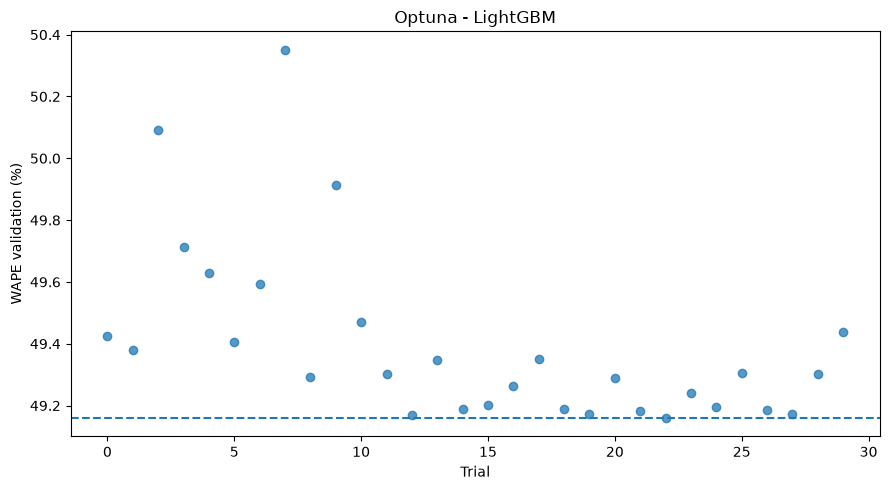

In [ ]:
def suggest_params(trial,name):
    if name=='LightGBM':
        return dict(n_estimators=trial.suggest_int('n_estimators',300,1200),learning_rate=trial.suggest_float('learning_rate',.01,.12,log=True),num_leaves=trial.suggest_int('num_leaves',20,160),max_depth=trial.suggest_int('max_depth',4,14),min_child_samples=trial.suggest_int('min_child_samples',20,200),subsample=trial.suggest_float('subsample',.7,1.),colsample_bytree=trial.suggest_float('colsample_bytree',.7,1.),reg_alpha=trial.suggest_float('reg_alpha',1e-5,10,log=True),reg_lambda=trial.suggest_float('reg_lambda',1e-5,10,log=True))
    if name=='XGBoost':
        return dict(n_estimators=trial.suggest_int('n_estimators',300,1200),learning_rate=trial.suggest_float('learning_rate',.01,.12,log=True),max_depth=trial.suggest_int('max_depth',4,12),min_child_weight=trial.suggest_float('min_child_weight',1,20),subsample=trial.suggest_float('subsample',.7,1.),colsample_bytree=trial.suggest_float('colsample_bytree',.7,1.),gamma=trial.suggest_float('gamma',0,5),reg_alpha=trial.suggest_float('reg_alpha',1e-5,10,log=True),reg_lambda=trial.suggest_float('reg_lambda',1e-5,10,log=True))
    if name=='CatBoost':
        return dict(iterations=trial.suggest_int('iterations',300,1200),learning_rate=trial.suggest_float('learning_rate',.01,.12,log=True),depth=trial.suggest_int('depth',5,10),l2_leaf_reg=trial.suggest_float('l2_leaf_reg',1e-3,20,log=True),random_strength=trial.suggest_float('random_strength',0,5),bagging_temperature=trial.suggest_float('bagging_temperature',0,5))
    raise ValueError(name)

def objective(trial):
    m=build_model(BEST_MODEL_NAME,suggest_params(trial,BEST_MODEL_NAME)); m.fit(X_tune_train,y_tune_train)
    pred=predictions_to_kwh(m.predict(X_tune_val),tune_val.scale_28d)
    return regression_metrics(tune_val.target,pred)['WAPE_pct']

study=optuna.create_study(direction='minimize',sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study.optimize(objective,n_trials=N_OPTUNA_TRIALS,show_progress_bar=True)
print('Best WAPE:',study.best_value); print(study.best_params)
with open(ARTIFACTS_DIR/'optuna_best_params.json','w',encoding='utf-8') as f: json.dump(study.best_params,f,indent=2)

trials=study.trials_dataframe(); plt.figure(figsize=(9,5)); plt.scatter(trials.number,trials.value,alpha=.75); plt.axhline(study.best_value,ls='--'); plt.xlabel('Trial'); plt.ylabel('WAPE validation (%)'); plt.title(f'Optuna - {BEST_MODEL_NAME}'); plt.tight_layout(); plt.show()

Reentrenamiento final con train + validation completo:

In [ ]:
final_sample=build_sample_dataset({'train':FINAL_TRAIN_DAYS_PER_USER,'validation':FINAL_VAL_DAYS_PER_USER})
final_trainval=final_sample[final_sample.split.isin(['train','validation']) & (final_sample.target_imputed==0)].copy()
X_final,y_final=prepare_xy(final_trainval,BEST_FEATURES)
FINAL_MODEL=build_model(BEST_MODEL_NAME,study.best_params); FINAL_MODEL.fit(X_final,y_final)
joblib.dump(FINAL_MODEL,ARTIFACTS_DIR/'final_24h_model.pkl')
joblib.dump(BEST_FEATURES,ARTIFACTS_DIR/'final_24h_features.pkl')
with open(ARTIFACTS_DIR/'final_24h_config.json','w',encoding='utf-8') as f:
    json.dump({'algorithm':BEST_MODEL_NAME,'source_variant':BEST_VARIANT_NAME,'features':BEST_FEATURES,'optuna_best_params':study.best_params,'forecast_horizon':24,'origin_local_hour':FORECAST_ORIGIN_LOCAL_HOUR,'train_end':str(TRAIN_END_DATE),'val_end':str(VAL_END_DATE),'test_end':str(TEST_END_DATE),'max_imputed_pct':MAX_IMPUTED_PCT},f,indent=2,ensure_ascii=False)
print('Modelo final guardado')

Muestra {'train': 120, 'validation': 60}:   0%|          | 0/1010 [00:00<?, ?it/s]

Muestra {'train': 120, 'validation': 60}: 100%|██████████| 1010/1010 [15:56<00:00,  1.06it/s]


Modelo final guardado


Evaluación final sobre test:

In [ ]:
def add_parts(total,y,p):
    y=np.asarray(y,dtype=float); p=np.asarray(p,dtype=float); v=np.isfinite(y)&np.isfinite(p); y=y[v]; p=p[v]
    if len(y)==0: return total
    e=p-y; part={'n':len(y),'sae':np.abs(e).sum(),'sse':(e**2).sum(),'sum_abs_y':np.abs(y).sum(),'smape_sum':(2*np.abs(e)/np.maximum(np.abs(y)+np.abs(p),1e-8)).sum(),'sum_y':y.sum(),'sum_y2':(y**2).sum()}
    if total is None: return part
    for k in total: total[k]+=part[k]
    return total

def finish(parts):
    sst=parts['sum_y2']-(parts['sum_y']**2)/parts['n']
    return {'n':int(parts['n']),'MAE':parts['sae']/parts['n'],'RMSE':np.sqrt(parts['sse']/parts['n']),'WAPE_pct':100*parts['sae']/max(parts['sum_abs_y'],1e-8),'sMAPE_pct':100*parts['smape_sum']/parts['n'],'R2':1-parts['sse']/sst if sst>0 else np.nan}

def evaluate_streaming(model,features,split_name,allowed_users):
    pf=pq.ParquetFile(FILTERED_CONSUMPTION); total=None; hp={h:None for h in range(1,25)}; user_rows=[]
    for rg in tqdm(range(pf.num_row_groups),desc=f'Evaluando {split_name}'):
        g=pf.read_row_group(rg).to_pandas()
        for uid,udf in g.groupby('user_id',sort=False):
            uid=str(uid)
            if uid not in allowed_users: continue
            rows=build_forecast_rows_for_user(udf,{split_name:None}); rows=rows[rows.target_imputed==0].copy()
            if rows.empty: continue
            X,_=prepare_xy(rows,features); pred=predictions_to_kwh(model.predict(X),rows.scale_28d); y=rows.target.to_numpy()
            total=add_parts(total,y,pred); up=add_parts(None,y,pred); user_rows.append({'user_id':uid,'split':split_name,**finish(up)})
            for h in range(1,25):
                m=rows.horizon.to_numpy()==h; hp[h]=add_parts(hp[h],y[m],pred[m])
    return {'split':split_name,**finish(total)}, pd.DataFrame([{'horizon':h,**finish(p)} for h,p in hp.items() if p is not None]), pd.DataFrame(user_rows)

test_overall,test_by_horizon,test_by_user=evaluate_streaming(FINAL_MODEL,BEST_FEATURES,'test',evaluation_users)
pd.DataFrame([test_overall]).to_csv(ARTIFACTS_DIR/'final_test_metrics.csv',index=False)
test_by_horizon.to_csv(ARTIFACTS_DIR/'final_test_metrics_by_horizon.csv',index=False)
test_by_user.to_csv(ARTIFACTS_DIR/'final_test_metrics_by_user.csv',index=False)
display(pd.DataFrame([test_overall])); display(test_by_horizon)

Evaluando test: 100%|██████████| 1010/1010 [17:41<00:00,  1.05s/it]


,split,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,test,4027323,0.111205,0.25515,52.62625,48.150019,0.420792


,horizon,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,1,167854,0.134649,0.270986,45.097522,44.864122,0.516614
1,2,167832,0.113909,0.242859,46.680197,45.754733,0.522868
2,3,167854,0.090063,0.210654,47.090287,44.277589,0.550513
3,4,166911,0.067689,0.183376,46.144550,40.661901,0.505589
4,5,167835,0.052483,0.162634,42.142040,36.770972,0.603658
5,6,167836,0.044210,0.147770,38.771665,34.356360,0.683051
6,7,167836,0.041379,0.145868,38.304504,33.367974,0.638487
7,8,167836,0.043519,0.153962,39.581252,33.766680,0.606806
8,9,167838,0.055703,0.171345,42.753388,37.201910,0.579412
9,10,167839,0.084732,0.211021,47.226209,43.308328,0.521873


Comparación final con baselines en test:

In [ ]:
def evaluate_baselines_streaming(split_name,allowed_users):
    pf=pq.ParquetFile(FILTERED_CONSUMPTION); totals={n:None for n in ['Naive_D-1','Naive_W-1','Naive_mean_D1_W1']}
    for rg in tqdm(range(pf.num_row_groups),desc='Baselines test'):
        g=pf.read_row_group(rg).to_pandas()
        for uid,udf in g.groupby('user_id',sort=False):
            uid=str(uid)
            if uid not in allowed_users: continue
            rows=build_forecast_rows_for_user(udf,{split_name:None}); rows=rows[rows.target_imputed==0]
            if rows.empty: continue
            y=rows.target.to_numpy(); preds={'Naive_D-1':rows.lag_24_target.to_numpy(),'Naive_W-1':rows.lag_168_target.to_numpy(),'Naive_mean_D1_W1':(rows.lag_24_target.to_numpy()+rows.lag_168_target.to_numpy())/2}
            for n,p in preds.items(): totals[n]=add_parts(totals[n],y,p)
    return pd.DataFrame([{'model':n,**finish(p)} for n,p in totals.items()])

test_baselines=evaluate_baselines_streaming('test',evaluation_users)
final_test_comparison=pd.concat([test_baselines,pd.DataFrame([{'model':f'{BEST_MODEL_NAME}_Optuna_final',**{k:v for k,v in test_overall.items() if k!='split'}}])],ignore_index=True)
final_test_comparison.to_csv(ARTIFACTS_DIR/'final_test_comparison.csv',index=False)
display(final_test_comparison.sort_values('WAPE_pct'))

Baselines test: 100%|██████████| 1010/1010 [12:07<00:00,  1.39it/s]


,model,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
3,LightGBM_Optuna_final,4027323,0.111205,0.255150,52.626250,48.150019,0.420792
2,Naive_mean_D1_W1,4027323,0.138106,0.281054,65.356574,55.291603,0.297210
0,Naive_D-1,4027323,0.151616,0.325545,71.749884,56.948142,0.057096
1,Naive_W-1,4027323,0.156826,0.336504,74.215640,59.685367,-0.007453


Gráficos de las métricas finales:

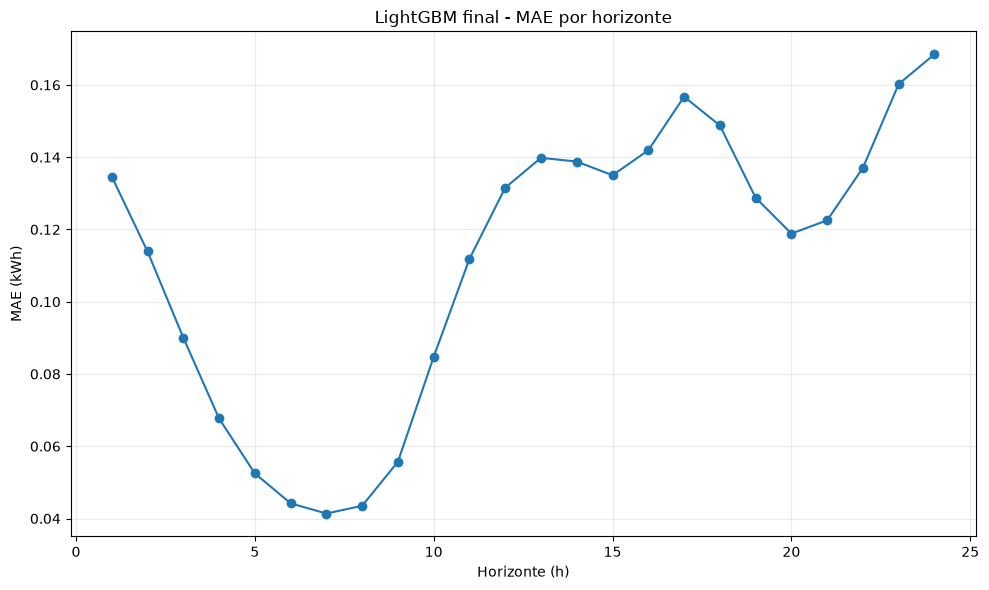

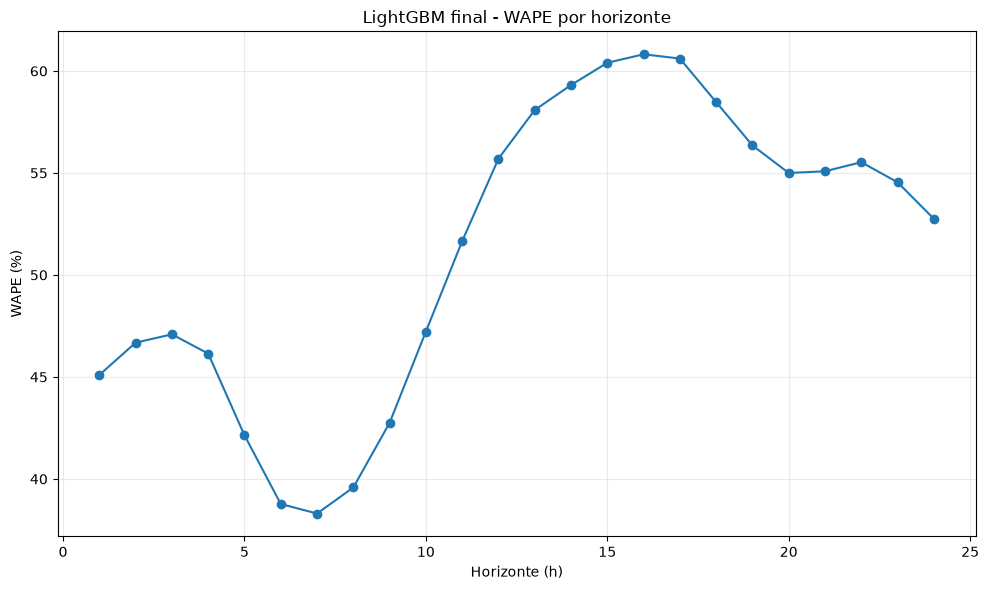

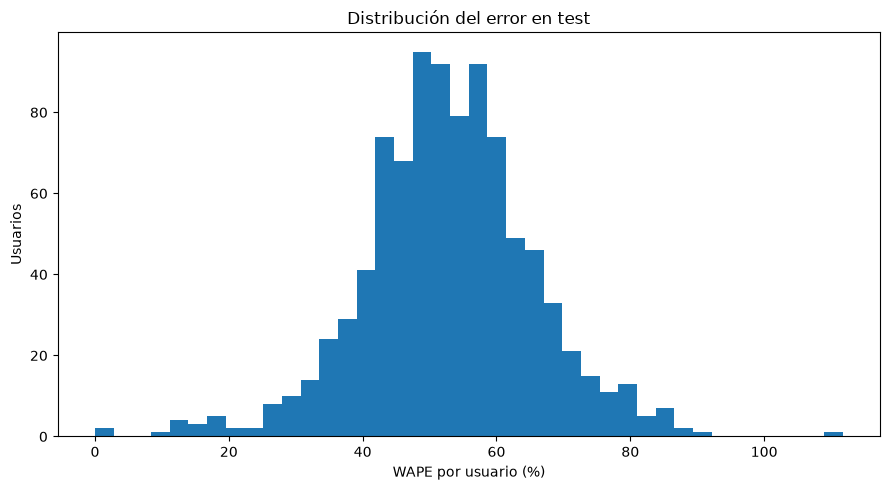

count    923.000000
mean      52.879310
std       12.776815
min        0.000000
10%       38.408569
25%       45.309523
50%       52.898767
75%       60.145483
90%       68.339613
95%       74.609948
max      111.726712
Name: WAPE_pct, dtype: float64

In [ ]:
plt.figure(figsize=(10,6)); plt.plot(test_by_horizon.horizon,test_by_horizon.MAE,marker='o'); plt.xlabel('Horizonte (h)'); plt.ylabel('MAE (kWh)'); plt.title(f'{BEST_MODEL_NAME} final - MAE por horizonte'); plt.grid(alpha=.25); plt.tight_layout(); plt.show()
plt.figure(figsize=(10,6)); plt.plot(test_by_horizon.horizon,test_by_horizon.WAPE_pct,marker='o'); plt.xlabel('Horizonte (h)'); plt.ylabel('WAPE (%)'); plt.title(f'{BEST_MODEL_NAME} final - WAPE por horizonte'); plt.grid(alpha=.25); plt.tight_layout(); plt.show()
plt.figure(figsize=(9,5)); plt.hist(test_by_user.WAPE_pct.dropna(),bins=40); plt.xlabel('WAPE por usuario (%)'); plt.ylabel('Usuarios'); plt.title('Distribución del error en test'); plt.tight_layout(); plt.show()
display(test_by_user.WAPE_pct.describe(percentiles=[.1,.25,.5,.75,.9,.95]))

Gráficos del consumo real vs estimado para usuarios representativos:

['d0de79a37cfd862eea948eb4dd5d57a0c5f617444c5f6a544d18b8b8a365600c', '6868b3f88ea0d6dba695ce6fa1613b484caf13b656085fc794470a506777404b', '4e75fd92fd4c0b7d74347f62e877ee490ed60c937bee4728b8ef82c8775ca53b']


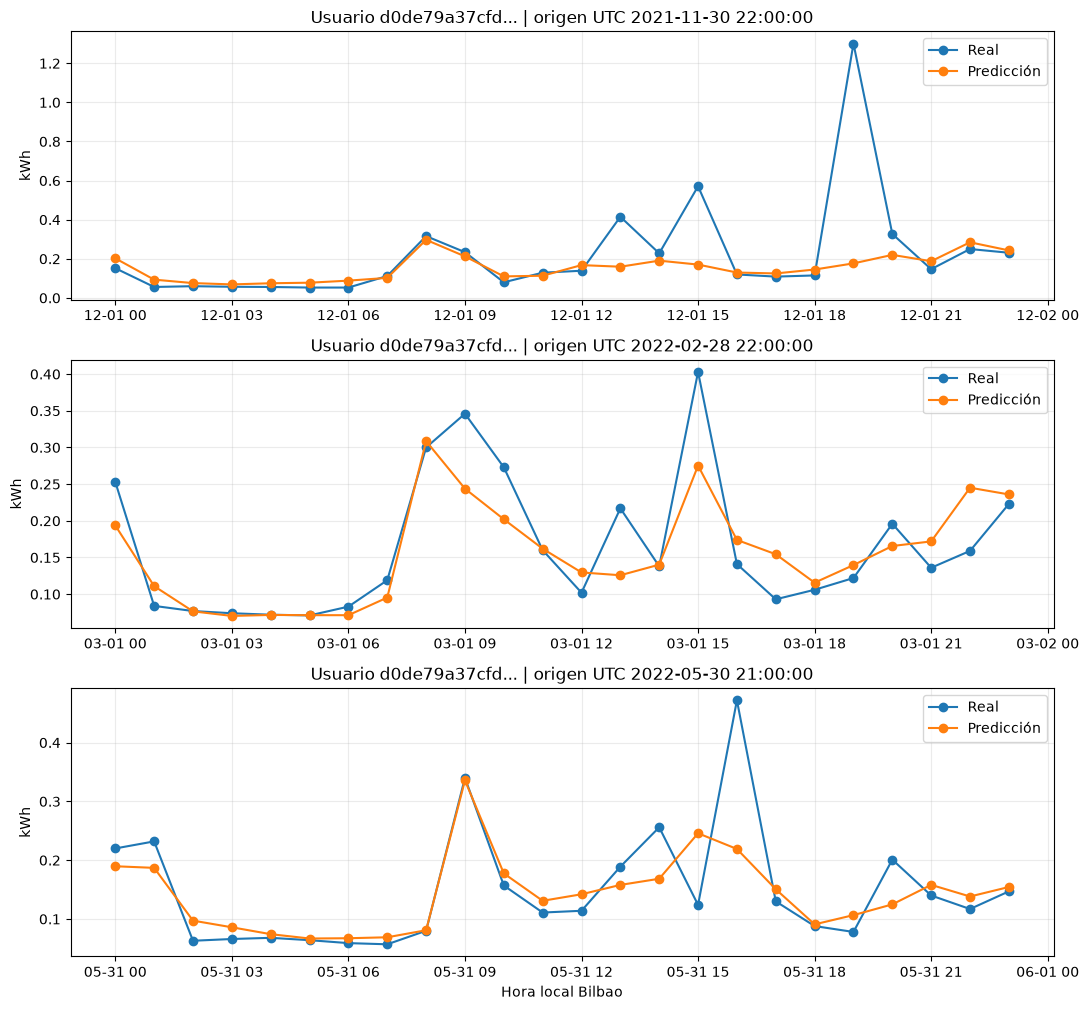

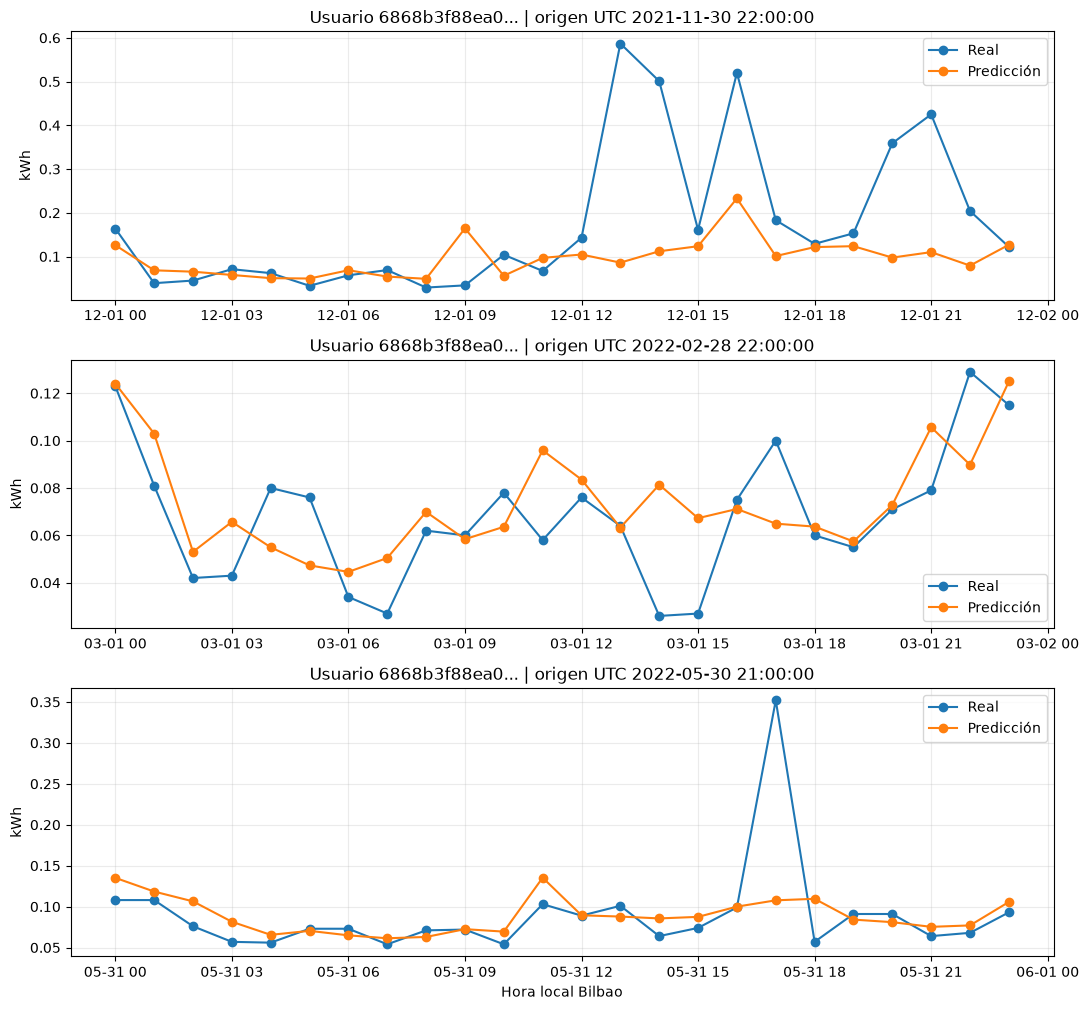

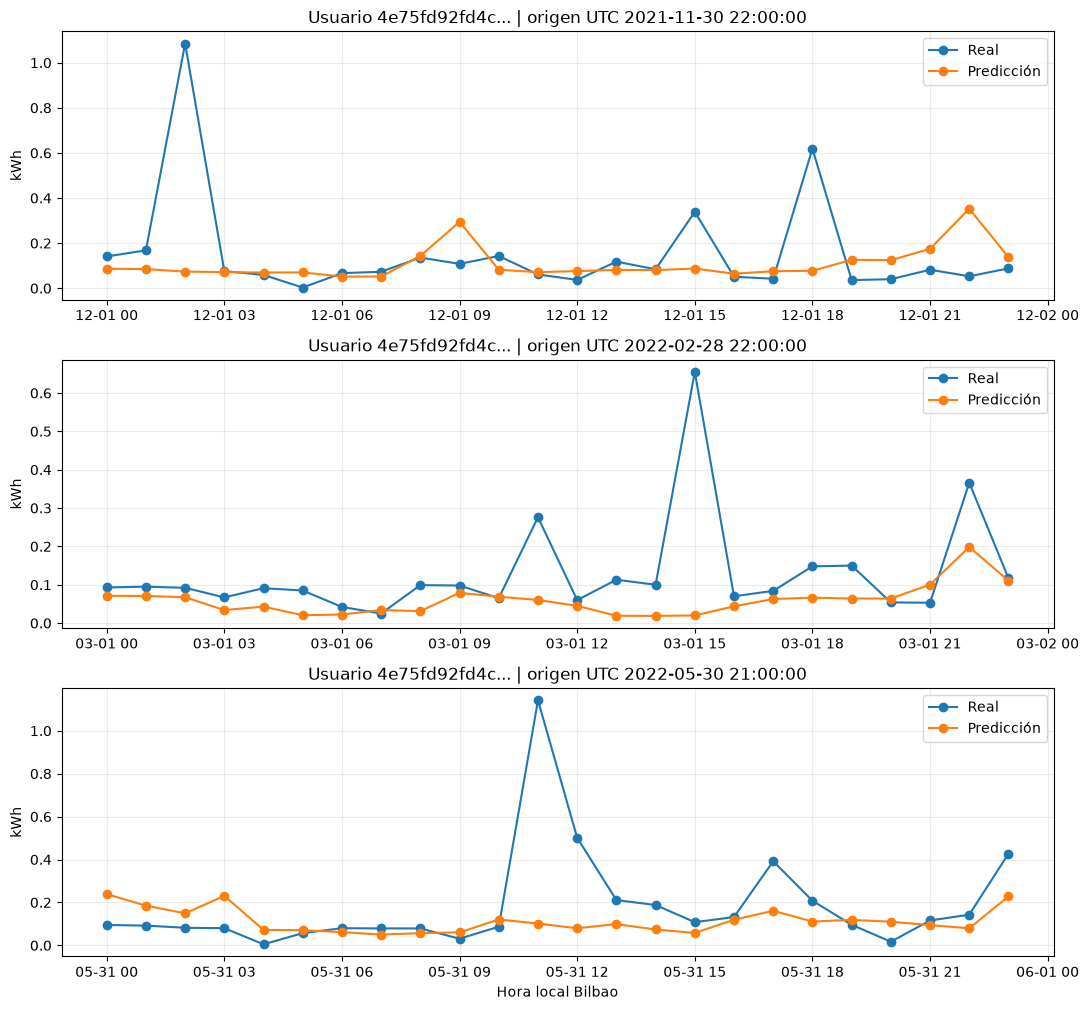

In [ ]:
su=test_by_user.sort_values('WAPE_pct').reset_index(drop=True)
plot_users=[su.iloc[max(0,int(.1*len(su))-1)].user_id,su.iloc[int(.5*len(su))].user_id,su.iloc[min(len(su)-1,int(.9*len(su)))].user_id]
print(plot_users)

def load_user(uid):
    pf=pq.ParquetFile(FILTERED_CONSUMPTION)
    for rg in range(pf.num_row_groups):
        g=pf.read_row_group(rg).to_pandas(); m=g.user_id.astype(str)==str(uid)
        if m.any(): return g[m].copy()
    raise KeyError(uid)

def get_plot_rows(uid,n_days=3):
    rows=build_forecast_rows_for_user(load_user(uid),{'test':None}); rows=rows[rows.target_imputed==0].copy()
    counts=rows.groupby('origin_time_utc').size(); origins=counts[counts==24].index
    if len(origins)==0: return pd.DataFrame()
    pos=np.linspace(0,len(origins)-1,num=min(n_days,len(origins)),dtype=int); chosen=origins[pos]; rows=rows[rows.origin_time_utc.isin(chosen)].copy()
    X,_=prepare_xy(rows,BEST_FEATURES); rows['prediction']=predictions_to_kwh(FINAL_MODEL.predict(X),rows.scale_28d)
    rows['target_time_local']=to_local_time(rows.target_time_utc).tz_localize(None)
    return rows

for uid in plot_users:
    r=get_plot_rows(uid,3)
    if r.empty: continue
    origins=r.origin_time_utc.drop_duplicates().tolist(); fig,axes=plt.subplots(len(origins),1,figsize=(11,3.4*len(origins)),squeeze=False)
    for ax,o in zip(axes.ravel(),origins):
        p=r[r.origin_time_utc==o].sort_values('horizon'); ax.plot(p.target_time_local,p.target,marker='o',label='Real'); ax.plot(p.target_time_local,p.prediction,marker='o',label='Predicción'); ax.set_title(f'Usuario {str(uid)[:12]}... | origen UTC {o}'); ax.set_ylabel('kWh'); ax.grid(alpha=.25); ax.legend()
    axes.ravel()[-1].set_xlabel('Hora local Bilbao'); fig.tight_layout(); plt.show()